# DAY 2 | ESS 배터리 수명 예측
SKALA 3반 · U095 · 이연주 | 2026-10-02

## 목적과 평가 원칙
초기 100사이클로 전체 Cycle Life를 예측하는 회귀 과제다. DAY 1에서 정한 피처와 정책 그룹 분리를 코드로 구현한다. Batch 1 개발용 29셀의 그룹 CV로만 후보를 선택하고, 정책이 겹치지 않는 7셀을 hold-out으로 평가한다. 이후 선택 사양을 Batch 1 전체 36셀로 재학습하여 Batch 2와 Batch 3에 적용한다.

단순 셀 단위 무작위 hold-out만으로 동일 정책 누수를 막을 수 없으므로 **정책 그룹 단위**로 분리한다. DAY 1 EDA에서 모든 배치를 이미 보았다는 한계는 남는다.

In [1]:
from pathlib import Path
import os, sys, json
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.environ['ESS_PROJECT_ROOT'] = str(ROOT)
os.environ.setdefault('MPLCONFIGDIR', str(ROOT/'results/day2/.cache/matplotlib'))
sys.path.insert(0, str(ROOT/'src'))
import pandas as pd
from IPython.display import display, Markdown, Image
import day2_modeling as d
OUT = ROOT/'results/day2'
pd.set_option('display.max_columns', 12)
cells, features, train, valid = d.prepare(ROOT, OUT)
display(pd.read_csv(OUT/'tables/cohort_counts.csv'))

Matplotlib is building the font cache; this may take a moment.


,batch,raw,labels,screened
0,Batch 1,46,46,36
1,Batch 2,47,39,39
2,Batch 3,46,44,40


## 1. 데이터 품질과 학습 범위
DAY 1의 사전 품질 규칙을 그대로 적용한다. 수명 라벨 결측, 종료 수명 미확인, 연속 실험 연결 불가, 사전 식별된 잡음 셀을 제외한다. 외부 평가 잔차를 보고 셀을 추가 제거하지 않는다. 원본은 139셀, 모델링 대상은 Batch 1/2/3 각각 36/39/40셀이다.

Batch 2 파일은 2018-02-20이다. 원논문의 2017-06-30 배치와 동일한 실험 재현으로 간주하지 않는다. 9.1%는 과제의 비교 기준이다.

Qdlin은 전압별 **방전 용량**이다. 셀 내부의 Q100-Q10과 그 분산을 사용한다. 동일 전압 격자 및 상수 오프셋에 대한 분산 불변성을 확인하되, 전압 의존적인 측정 차이까지 제거되었다고 주장하지 않는다.

In [2]:
display(pd.read_csv(OUT/'tables/source_manifest.csv'))
display(features.groupby(['batch','analysis_eligible','review_reason'], dropna=False).size().rename('n').reset_index())
display(pd.read_csv(OUT/'tables/voltage_alignment.csv').groupby('batch')[['voltage_points','voltage_min','voltage_max','q10_mean']].agg(['min','max']))

,batch,file,bytes,cell_count,fields
0,Batch 1,2017-05-12_batchdata_updated_struct_errorcorre...,3025320241,46,"Vdlin,barcode,channel_id,cycle_life,cycles,pol..."
1,Batch 2,2018-02-20_batchdata_updated_struct_errorcorre...,2022599329,47,"Vdlin,barcode,channel_id,cycle_life,cycles,pol..."
2,Batch 3,2018-04-12_batchdata_updated_struct_errorcorre...,3236690412,46,"Vdlin,barcode,channel_id,cycle_life,cycles,pol..."


,batch,analysis_eligible,review_reason,n
0,Batch 1,False,unresolved_EOl_or_continuation,10
1,Batch 1,True,,36
2,Batch 2,False,missing_target;special_protocol,8
3,Batch 2,True,,39
4,Batch 3,False,author_flagged_channel,4
5,Batch 3,False,missing_target;author_flagged_channel,2
6,Batch 3,True,,40


voltage_points       voltage_min      voltage_max       q10_mean  \
                   min   max         min  max         min  max       min   
batch                                                                      
Batch 1           1000  1000         2.0  2.0         3.5  3.5  0.735376   
Batch 2           1000  1000         2.0  2.0         3.5  3.5  0.723887   
Batch 3           1000  1000         2.0  2.0         3.5  3.5  0.730883   

                   
              max  
batch              
Batch 1  0.768368  
Batch 2  0.768619  
Batch 3  0.761400

## 2. DAY 1 전략 → 피처·파이프라인
- F1: log10 Var(ΔQ100-10). 배치별 수명과 일관된 음의 상관이 나타난 핵심 신호다.
- F2: F1 + 초기 Qd 기울기 + 등가 충전 C-rate. 열화 추세와 실험 조건의 추가 효용을 검증한다.
- F3: F2 + 초기 평균 온도 + 내부저항 중앙값. 약한 보조 신호가 일반화에 도움이 되는지 CV에서 검증한다.

후기 열화 곡선, knee, 마지막 용량, 전체 관측 사이클 수, Batch ID, 셀 ID는 입력에서 제외한다. 정책은 분할에만 사용한다. 결측 중앙값과 표준화는 Pipeline으로 각 fold 학습 데이터에서만 적합한다. 타깃 원값과 log10 변환을 비교하고 MAPE는 모두 원래 사이클 단위의 예측값으로 계산한다.

중앙값 기준모델, Ridge, ElasticNet, 얕은 Random Forest를 비교한다. 소표본의 분산을 줄이는 규제 선형 모델과 비선형 비교군이라는 DAY 1 논리를 따른다.

In [3]:
display(pd.DataFrame([{'set':k,'features':', '.join(v)} for k,v in d.SETS.items()]))
display(pd.concat([train.assign(role='train'),valid.assign(role='holdout')]).groupby('role').agg(cells=('cell_id','size'),policies=('policy','nunique')))
display(train.groupby('cv_fold').agg(cells=('cell_id','size'),policies=('policy','nunique')))
assert not set(train.policy) & set(valid.policy)
print('고정 후보 수:', len(d.candidates()), '| random_state:', d.SEED)

,set,features
0,F1,log_dq_var
1,F2,"log_dq_var, qd_slope, c_equiv"
2,F3,"log_dq_var, qd_slope, c_equiv, tavg_median, ir..."


,cells,policies
role,,
holdout,7,4
train,29,16


,cells,policies
cv_fold,,
0,8,4
1,7,4
2,7,4
3,7,4


고정 후보 수: 85 | random_state: 42


## 3. Batch 1 그룹 CV로만 모델 선택
29셀에서 고정 4-fold를 사용한다. 평균 MAPE 최소 사양을 선택하며 동률이면 피처 수, 후보 ID 순으로 결정한다. 이 단계는 hold-out 및 외부 배치 프레임을 받지 않는다. 85개 후보를 비교하므로 선택된 CV 성능에는 선택 낙관성이 존재한다. 별도의 nested CV 결과라고 해석하지 않는다.

In [4]:
best, comparison = d.select_model(train, OUT)
display(comparison.head(10))
display(comparison.groupby('feature_set',sort=False).head(1))
display(comparison.groupby('family',sort=False).head(1))
print('선택 사양:', best)

,candidate_id,family,feature_set,target,params,cv_mape,cv_std,cv_mae,cv_rmse,n_features
0,C010,ElasticNet,F1,raw,"{""alpha"": 0.1, ""l1_ratio"": 0.8}",9.209769,3.262336,72.908817,84.785435,1
1,C002,Ridge,F1,raw,"{""alpha"": 1.0}",9.212415,3.357662,72.817769,84.638514,1
2,C007,ElasticNet,F1,raw,"{""alpha"": 0.01, ""l1_ratio"": 0.2}",9.227445,3.175202,73.068293,84.872049,1
3,C009,ElasticNet,F1,raw,"{""alpha"": 0.1, ""l1_ratio"": 0.2}",9.229386,3.476966,72.791664,84.611644,1
4,C001,Ridge,F1,raw,"{""alpha"": 0.1}",9.231825,3.153233,73.108791,84.897859,1
5,C008,ElasticNet,F1,raw,"{""alpha"": 0.01, ""l1_ratio"": 0.8}",9.236263,3.135360,73.146726,84.922869,1
6,C005,ElasticNet,F1,raw,"{""alpha"": 0.001, ""l1_ratio"": 0.2}",9.238075,3.126833,73.163074,84.933764,1
7,C006,ElasticNet,F1,raw,"{""alpha"": 0.001, ""l1_ratio"": 0.8}",9.238965,3.122880,73.170988,84.939222,1
8,C016,Ridge,F1,log10,"{""alpha"": 1.0}",9.390313,3.033509,74.490594,88.434702,1
9,C015,Ridge,F1,log10,"{""alpha"": 0.1}",9.420183,2.889511,74.869620,89.022523,1


,candidate_id,family,feature_set,target,params,cv_mape,cv_std,cv_mae,cv_rmse,n_features
0,C010,ElasticNet,F1,raw,"{""alpha"": 0.1, ""l1_ratio"": 0.8}",9.209769,3.262336,72.908817,84.785435,1
14,C050,ElasticNet,F2,log10,"{""alpha"": 0.01, ""l1_ratio"": 0.8}",9.893512,3.581033,77.742411,91.610033,3
15,C078,ElasticNet,F3,log10,"{""alpha"": 0.01, ""l1_ratio"": 0.8}",9.893542,3.580974,77.742669,91.610427,5


,candidate_id,family,feature_set,target,params,cv_mape,cv_std,cv_mae,cv_rmse,n_features
0,C010,ElasticNet,F1,raw,"{""alpha"": 0.1, ""l1_ratio"": 0.8}",9.209769,3.262336,72.908817,84.785435,1
1,C002,Ridge,F1,raw,"{""alpha"": 1.0}",9.212415,3.357662,72.817769,84.638514,1
18,C025,RandomForest,F1,log10,"{""max_depth"": 2, ""min_samples_leaf"": 3}",10.044172,3.658353,76.632248,91.349815,1
84,C000,Dummy,F1,raw,{},15.056029,5.423135,115.116071,135.236054,1


선택 사양: {'id': 'C010', 'family': 'ElasticNet', 'set': 'F1', 'target': 'raw', 'params': {'alpha': 0.1, 'l1_ratio': 0.8}}


## 4. 선택 사양 고정 후 hold-out과 외부 배치 평가
선택 JSON과 해시를 기록한 뒤 hold-out을 평가한다. 최종 모델은 동일 사양으로 Batch 1 36셀에만 적합한다. Batch 2/3는 선택 모델과 사전 지정 중앙값 기준모델만 평가한다. 이 결과로 모델이나 하이퍼파라미터를 다시 고르지 않는다.

In [5]:
scores, predictions, required_report = d.evaluate(best, features, train, valid, OUT)
display(required_report.round(3))
display(pd.read_csv(OUT/'tables/model_performance_extended.csv').round(3))
display(scores.round(3))

,구분,MAPE (%),단위,비고
0,Train (Batch 1 CV),9.210,%,"29셀, 정책 그룹 4-fold 평균; SD 3.26%p"
1,Valid (Batch 1 Hold-out),9.199,%,29셀 학습 모델; 미사용 정책 7셀 평가
2,Test (Batch 2),26.209,%,Batch 1 전체 36셀 재학습; Batch 2 39셀
3,Gap (Train-Valid),-0.011,%p,Valid - CV; (+)이면 과적합 또는 분할 난도 차이 의심
4,Gap (Valid-Test),17.010,%p,Batch 2 - Valid; (+)이면 일반화 저하 의심
5,Gap (Target-Test),17.109,%p,Batch 2 - 9.1; (+)이면 논문 기준보다 높은 오차


,구분,MAPE (%),단위,비고
0,Train (Batch 1 CV),9.210,%,"29셀, 정책 그룹 4-fold 평균; SD 3.26%p"
1,Valid (Batch 1 Hold-out),9.199,%,29셀 학습 모델; 미사용 정책 7셀 평가
2,Test (Batch 2),26.209,%,Batch 1 전체 36셀 재학습; Batch 2 39셀
3,Gap (Train-Valid),-0.011,%p,Valid - CV; (+)이면 과적합 또는 분할 난도 차이 의심
4,Gap (Valid-Test),17.010,%p,Batch 2 - Valid; (+)이면 일반화 저하 의심
5,Gap (Target-Test),17.109,%p,Batch 2 - 9.1; (+)이면 논문 기준보다 높은 오차
6,Test (Batch 3),12.163,%,동일 최종 모델; Batch 3 40셀
7,Gap (Batch2-Batch3),-14.046,%p,Batch 3 - Batch 2; (+)이면 Batch 3 오차 증가
8,Gap (Target-Test) [Batch 3],3.063,%p,Batch 3 - 9.1; 과제 공통 기준과 비교


,dataset,n,fit_cells,MAPE_pct,MAE_cycles,RMSE_cycles,R2,baseline_MAPE_pct
0,Valid (Batch 1 Hold-out),7,29,9.199,78.844,93.284,0.760,22.136
1,Test (Batch 2),39,36,26.209,131.799,154.517,0.504,58.728
2,Test (Batch 3),40,36,12.163,144.187,234.504,0.408,22.899


## 5. 성능 지표와 Gap 해석
MAPE = mean(|예측-실제|/실제) × 100이다. Train은 재대입 성능이 아니라 4개 검증 fold의 MAPE 산술평균이다. 각 fold의 셀 수가 다르므로 전체 OOF를 합친 MAPE와 다를 수 있다.

과제의 양수=성능 저하 의미에 맞춰 Gap(Train-Valid)=Valid-CV, Gap(Valid-Test)=Test-Valid, Gap(Target-Test)=Test-9.1로 정의한다. Gap 단위는 %p다. Valid는 29셀 학습, Test는 36셀 재학습이므로 Gap은 배치 차이만을 고립한 인과 효과가 아니다. 작은 hold-out의 난도·표본 변동도 영향을 준다.

MAE, RMSE, R²를 함께 제시한다. 정책 단위 bootstrap 구간은 고정 모델의 탐색적 평가 불확실성이며, 학습·모델 선택의 불확실성을 모두 포함하지 않는다.

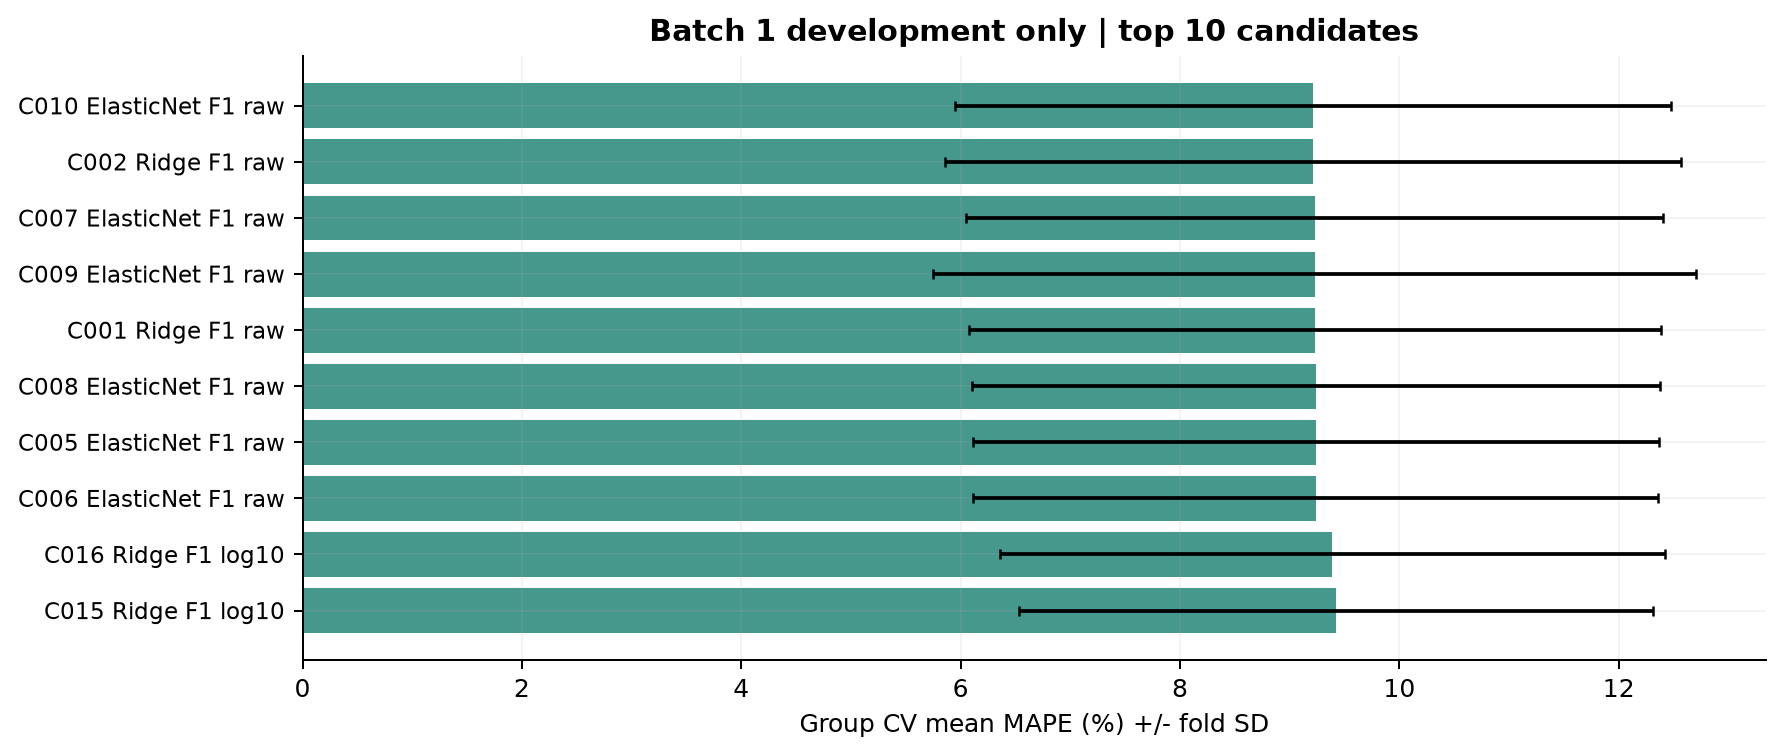

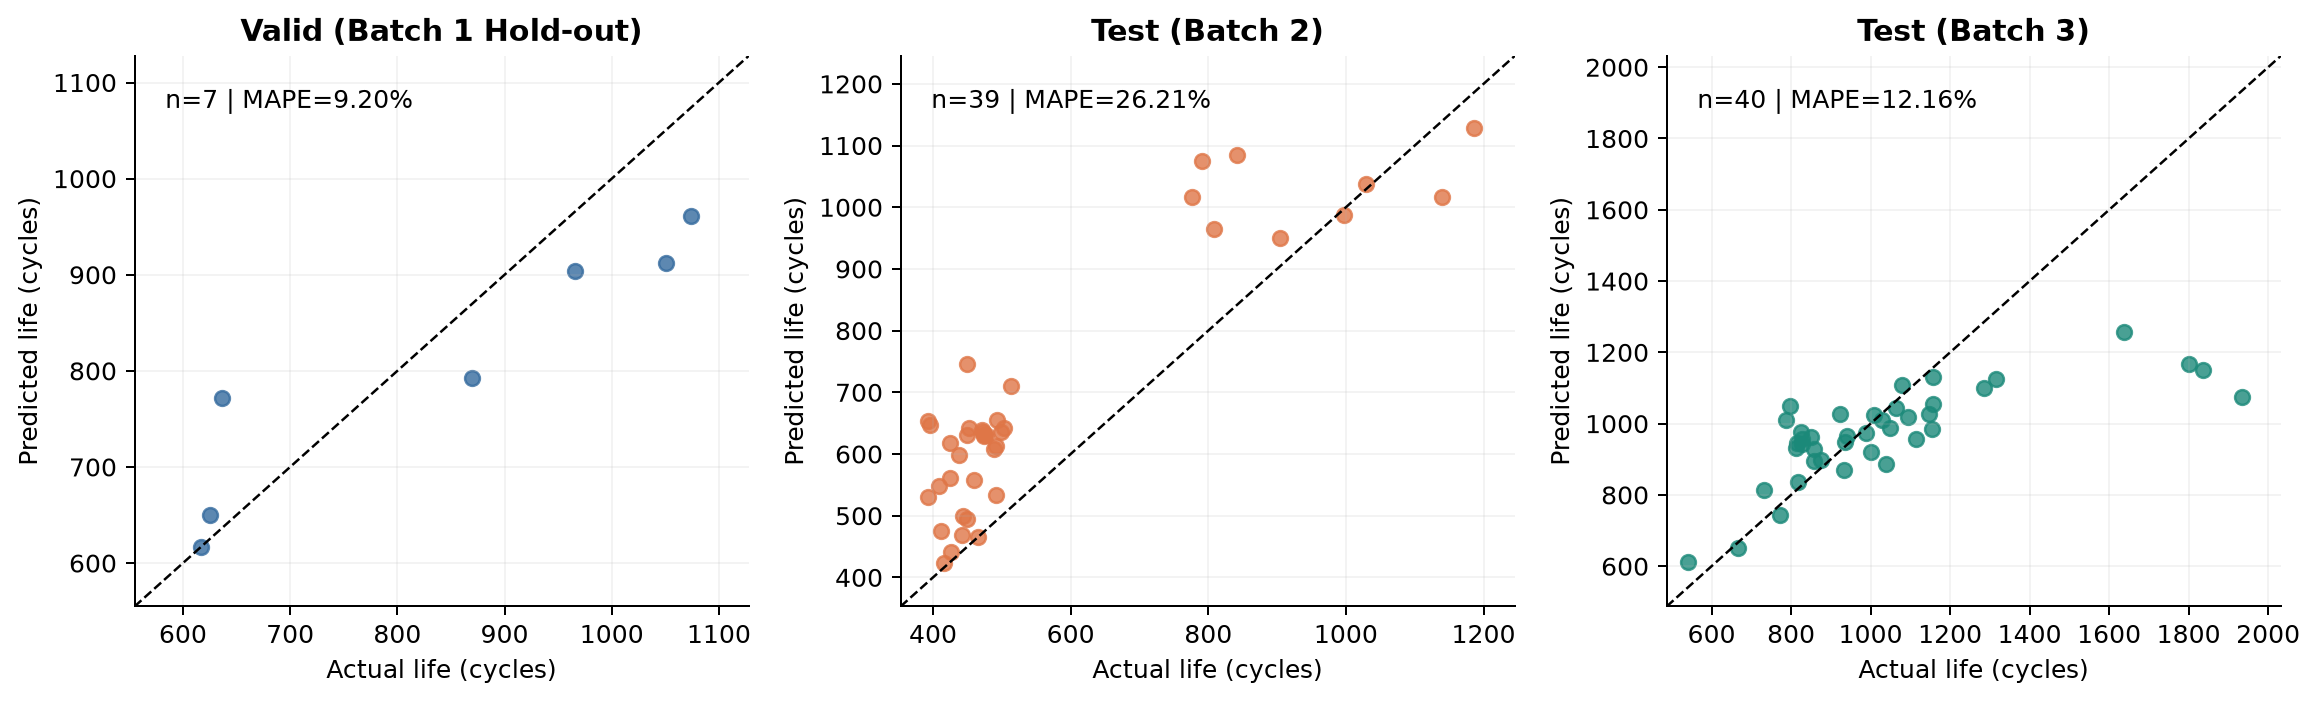

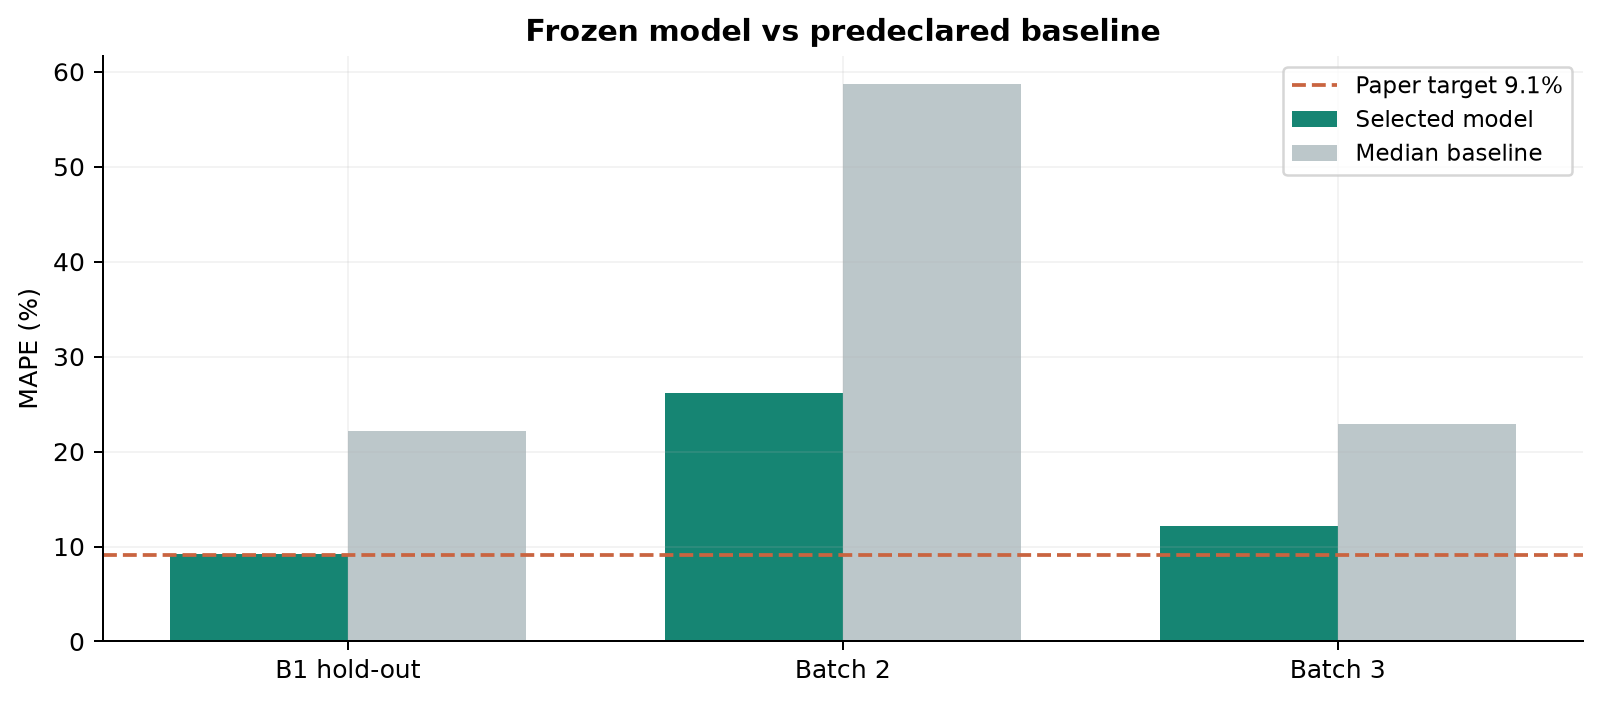

,dataset,n_policies,MAPE_pct,policy_bootstrap_lo,policy_bootstrap_hi
0,Valid (Batch 1 Hold-out),4,9.199,3.959,13.582
1,Test (Batch 2),12,26.209,18.249,34.355
2,Test (Batch 3),8,12.163,8.177,16.518


In [6]:
d.plots(best, comparison, predictions, OUT)
for name in ['01_cv_selection','02_actual_predicted','04_performance']:
    display(Image(filename=str(OUT/'figures'/f'{name}.png')))
display(pd.read_csv(OUT/'tables/uncertainty.csv').round(3))

## 6. 오류와 배치 차이 분석
같은 최종 모델의 Batch 2/3 잔차를 비교한다. 수명이 짧은 셀은 동일한 사이클 오차에도 MAPE 기여도가 커진다. 실제 수명이 학습 범위를 벗어나는 셀의 오차 및 초기 피처 범위 이탈을 분리하여 확인한다. 이는 평가 후 진단이며, 외부 셀 제거 또는 재학습의 근거로 사용하지 않는다.

,dataset,life_band,n,MAPE_pct,bias_cycles
0,Test (Batch 2),<500,28,29.239,129.875
1,Test (Batch 2),500-999,8,23.373,161.856
2,Test (Batch 2),>=1000,3,5.492,-57.643
3,Test (Batch 3),500-999,21,10.668,74.210
4,Test (Batch 3),>=1000,19,13.815,-203.703
5,Valid (Batch 1 Hold-out),500-999,5,8.134,4.096
6,Valid (Batch 1 Hold-out),>=1000,2,11.861,-125.868


,dataset,cell_id,batch,policy,actual,predicted,residual,APE_pct,baseline_predicted,life_outside_train_range
0,Test (Batch 2),b2c6,Batch 2,3.6C(9%)-5C,393.0,653.496,260.496,66.284,772.5,True
1,Test (Batch 2),b2c18,Batch 2,5.2C(50%)-4.25C,449.0,745.178,296.178,65.964,772.5,True
2,Test (Batch 2),b2c15,Batch 2,3.6C(9%)-5C,396.0,646.365,250.365,63.223,772.5,True
3,Test (Batch 2),b2c2,Batch 2,5.2C(50%)-4.25C,424.0,617.399,193.399,45.613,772.5,True
4,Test (Batch 3),b3c38,Batch 3,5C(67%)-4C-newstructure,1935.0,1073.477,-861.523,44.523,772.5,True
5,Test (Batch 2),b2c29,Batch 2,5.2C(58%)-4C,452.0,642.225,190.225,42.085,772.5,True
6,Test (Batch 3),b3c7,Batch 3,4.8C(80%)-4.8C-newstructure,1836.0,1149.346,-686.654,37.399,772.5,True
7,Test (Batch 3),b3c45,Batch 3,4.8C(80%)-4.8C-newstructure,1801.0,1165.952,-635.048,35.261,772.5,True
8,Test (Batch 3),b3c40,Batch 3,5.6C(19%)-4.6C-newstructure,796.0,1049.196,253.196,31.809,772.5,False
9,Test (Batch 3),b3c41,Batch 3,5.6C(36%)-4.3C-newstructure,786.0,1010.096,224.096,28.511,772.5,False


,batch,feature,n,train_min,train_max,median,mean_shift_train_sd,outside_train_pct
0,Batch 1,log_dq_var,36,-4.178,-3.35,-3.786,0.000,0.00
1,Batch 2,log_dq_var,39,-4.178,-3.35,-3.487,0.836,43.59
2,Batch 3,log_dq_var,40,-4.178,-3.35,-4.150,-1.543,42.50


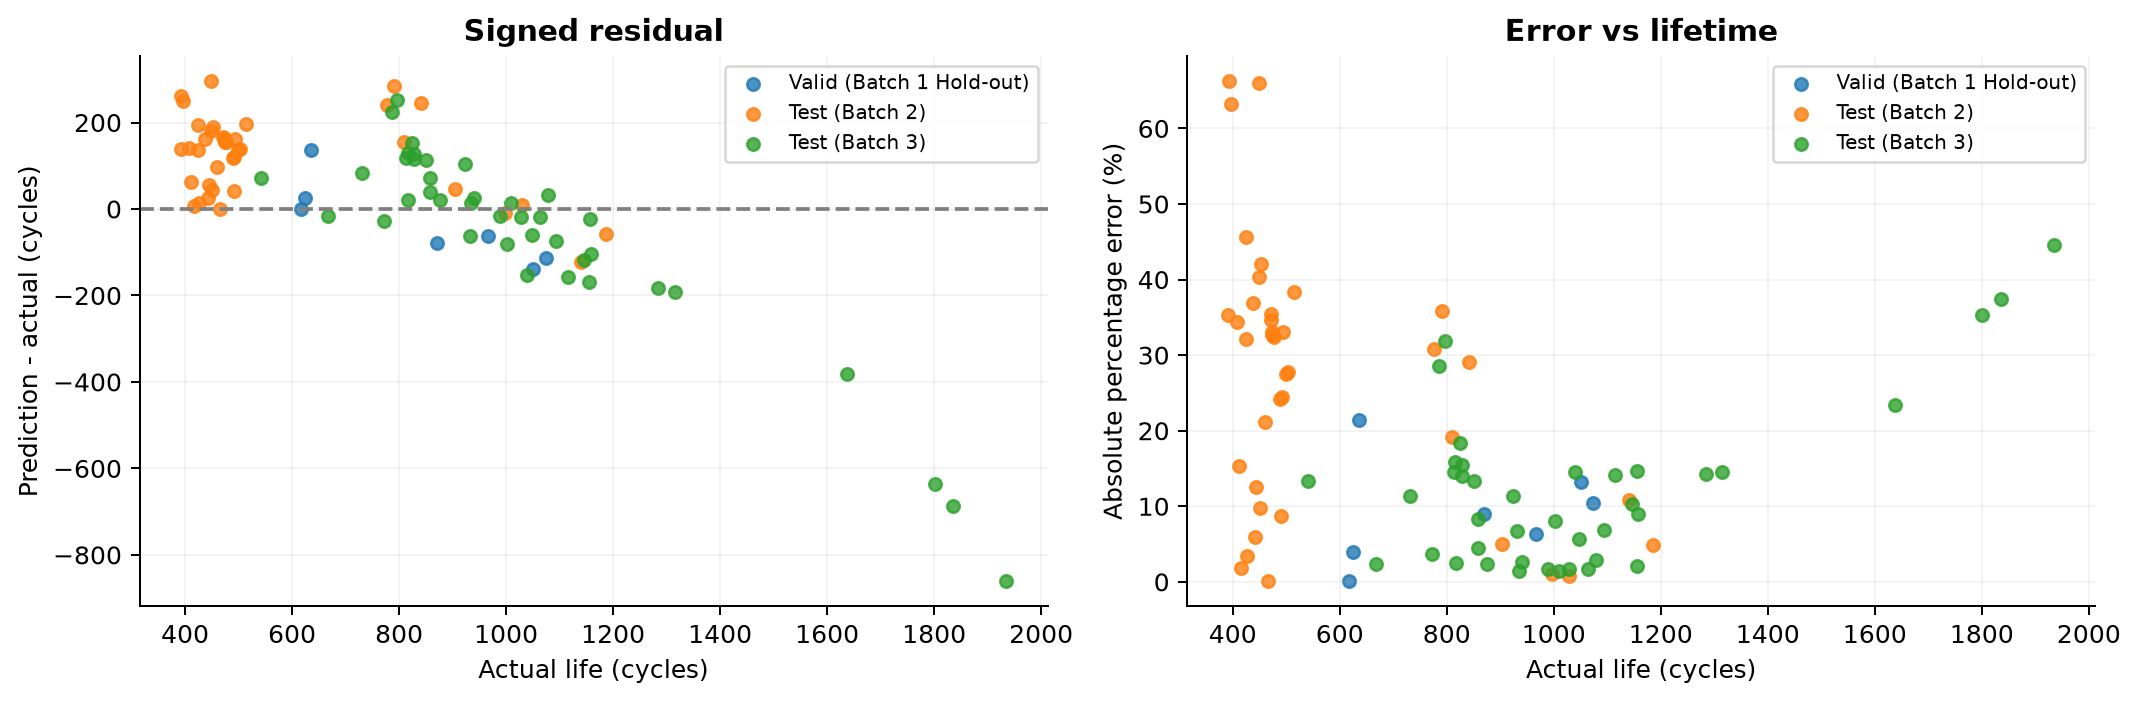

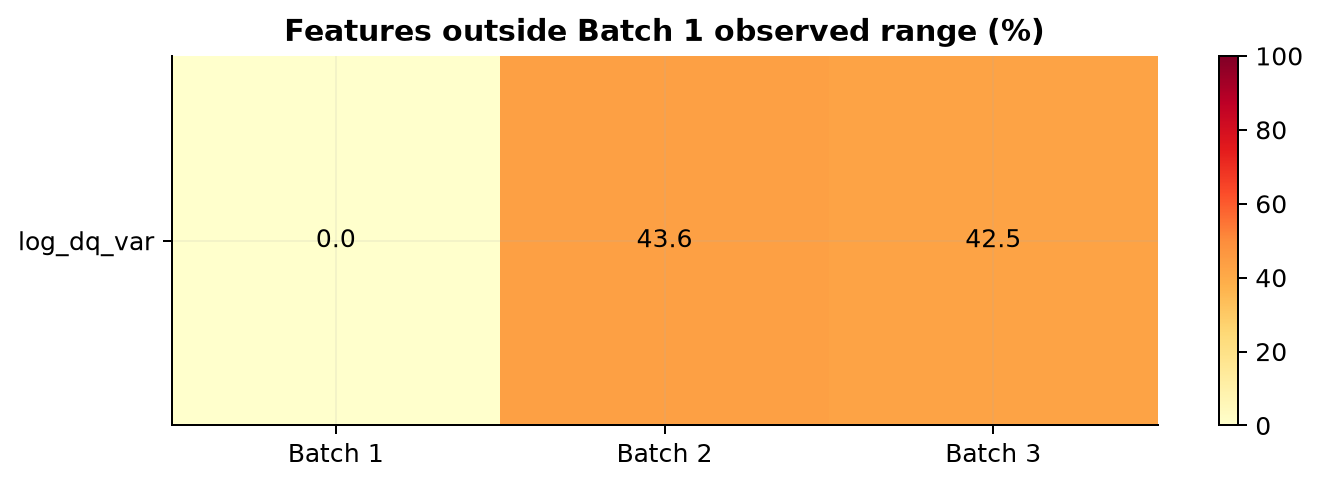

,feature,coefficient_standardized
0,log_dq_var,-118.735749


In [7]:
display(pd.read_csv(OUT/'tables/error_by_life_band.csv').round(3))
display(pd.read_csv(OUT/'tables/largest_errors.csv').round(3))
display(pd.read_csv(OUT/'tables/feature_drift.csv').round(3))
for name in ['03_residuals','05_feature_drift']:
    display(Image(filename=str(OUT/'figures'/f'{name}.png')))
explanation=OUT/'tables/model_explanation.csv'
if explanation.exists(): display(pd.read_csv(explanation))

In [8]:
cv=float(comparison.iloc[0].cv_mape)
v,b2,b3=scores.MAPE_pct.to_list()
display(Markdown(f"""## 7. 실행 결과 요약
선택 모델은 **{best['family']} / {best['set']} / {best['target']} 타깃**이다. 비교한 85개 사양 중 개발 CV MAPE가 가장 낮은 모델이며, 모든 가능한 모델 중 최적이라는 뜻은 아니다.

CV **{cv:.2f}%**, hold-out **{v:.2f}%**, Batch 2 **{b2:.2f}%**, Batch 3 **{b3:.2f}%**다. Batch 2의 논문 기준 대비 Gap은 **{b2-9.1:+.2f}%p**다. Batch 3와 Batch 2의 차이는 **{b3-b2:+.2f}%p**다.

초기 열화 신호의 예측 유용성을 확인하되, 실험 배치·품질 필터·학습 규모가 논문과 다르므로 직접적인 우열이나 동일 조건 재현을 주장하지 않는다. 실제 ESS 운용 데이터나 다른 화학계로의 적용은 별도의 시간·장비·정책 독립 검증이 필요하다.

후속 개선은 신규 독립 데이터 확보, 정책 그룹 nested CV, 배치별 센서 정합성 점검, 예측 구간 및 입력/잔차 drift 모니터링이다. 현재 테스트 결과를 보고 반복 튜닝하면 기존 테스트는 개발 데이터가 되므로 새 테스트셋이 필요하다.
"""))
d.write_json(OUT/'environment.json',{'python':d.platform.python_version(),'random_state':d.SEED,
    'libraries':{p:d.metadata.version(p) for p in ['numpy','pandas','scipy','h5py','scikit-learn','matplotlib','joblib','nbformat','nbclient']}})
assert d.digest(OUT/'selected_model.json')==json.loads((OUT/'evaluation_record.json').read_text())['selection_sha256']
print('실행 및 선택 사양 고정 확인 완료')

## 7. 실행 결과 요약
선택 모델은 **ElasticNet / F1 / raw 타깃**이다. 비교한 85개 사양 중 개발 CV MAPE가 가장 낮은 모델이며, 모든 가능한 모델 중 최적이라는 뜻은 아니다.

CV **9.21%**, hold-out **9.20%**, Batch 2 **26.21%**, Batch 3 **12.16%**다. Batch 2의 논문 기준 대비 Gap은 **+17.11%p**다. Batch 3와 Batch 2의 차이는 **-14.05%p**다.

초기 열화 신호의 예측 유용성을 확인하되, 실험 배치·품질 필터·학습 규모가 논문과 다르므로 직접적인 우열이나 동일 조건 재현을 주장하지 않는다. 실제 ESS 운용 데이터나 다른 화학계로의 적용은 별도의 시간·장비·정책 독립 검증이 필요하다.

후속 개선은 신규 독립 데이터 확보, 정책 그룹 nested CV, 배치별 센서 정합성 점검, 예측 구간 및 입력/잔차 drift 모니터링이다. 현재 테스트 결과를 보고 반복 튜닝하면 기존 테스트는 개발 데이터가 되므로 새 테스트셋이 필요하다.


실행 및 선택 사양 고정 확인 완료


## 재현과 참고
프로젝트 루트에서 Jupyter를 열어 이 노트북을 위에서 아래로 전체 실행한다. 원본 MAT 데이터는 `data/`에 있어야 한다. 모델은 신뢰할 수 있는 로컬 joblib 파일만 로드한다.

- Severson et al. (2019), Nature Energy: https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf
- GroupKFold: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupKFold.html
- TransformedTargetRegressor: https://scikit-learn.org/stable/modules/generated/sklearn.compose.TransformedTargetRegressor.html